In [1]:
import kagglehub
import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt
import os

# Download latest version
path = kagglehub.dataset_download("anikannal/solar-power-generation-data")


100%|██████████| 1.90M/1.90M [00:00<00:00, 106MB/s]

Extracting files...


In [2]:

gen_df = pd.read_csv(path + '/Plant_1_Generation_Data.csv')
weather_df = pd.read_csv(path+"/Plant_1_Weather_Sensor_Data.csv")

print("Pierwsze 5 wierszy tabeli generacji:")
display(gen_df.head())

print("\nInformacje o kolumnach:")
gen_df.info()

Pierwsze 5 wierszy tabeli generacji:


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0



Informacje o kolumnach:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.7+ MB


In [3]:
gen_df['DATE_TIME'] = pd.to_datetime(gen_df['DATE_TIME'])
weather_df['DATE_TIME'] = pd.to_datetime(weather_df['DATE_TIME'])

gen_df.info()
weather_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE_TIME    68778 non-null  datetime64[ns]
 1   PLANT_ID     68778 non-null  int64         
 2   SOURCE_KEY   68778 non-null  object        
 3   DC_POWER     68778 non-null  float64       
 4   AC_POWER     68778 non-null  float64       
 5   DAILY_YIELD  68778 non-null  float64       
 6   TOTAL_YIELD  68778 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 3.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            3182 non-null   datetime64[ns]
 1   PLANT_ID             3182 non-null   int64         
 2   SOURCE_KEY           3182 non-n

/tmp/ipython-input-1342120003.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  gen_df['DATE_TIME'] = pd.to_datetime(gen_df['DATE_TIME'])


In [4]:
df = pd.merge(gen_df, weather_df, on='DATE_TIME', how='left')
df.head()

,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,4135001.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


In [5]:
df[(df['IRRADIATION'] > 0.1) & (df['DC_POWER'] == 0)].head()

,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
815,2020-05-15 09:15:00,4135001,zVJPv84UY57bAof,0.0,0.0,711.0,7116862.0,4135001.0,HmiyD2TTLFNqkNe,27.988362,46.617706,0.344884
837,2020-05-15 09:30:00,4135001,zVJPv84UY57bAof,0.0,0.0,711.0,7116862.0,4135001.0,HmiyD2TTLFNqkNe,27.516728,39.136326,0.249248
18490,2020-05-24 15:15:00,4135001,zBIq5rxdHJRwDNY,0.0,0.0,6464.0,6410945.0,4135001.0,HmiyD2TTLFNqkNe,33.761304,54.006864,0.476600
20103,2020-05-25 10:15:00,4135001,ih0vzX44oOqAx2f,0.0,0.0,1795.0,6258289.0,4135001.0,HmiyD2TTLFNqkNe,29.217751,53.501414,0.834157
46679,2020-06-07 12:15:00,4135001,bvBOhCH3iADSZry,0.0,0.0,3551.0,6476675.0,4135001.0,HmiyD2TTLFNqkNe,28.748334,59.987771,1.024229


In [6]:
df = df[df['IRRADIATION'] > 0]

In [7]:
df['EFFICIENCY'] = df['AC_POWER']/df['IRRADIATION']
df['EFFICIENCY'].describe()

,EFFICIENCY
count,38376.000000
mean,1285.818786
std,301.867388
min,0.000000
25%,1260.788233
50%,1349.335008
75%,1423.860247
max,2764.098224


<function matplotlib.pyplot.show(close=None, block=None)>

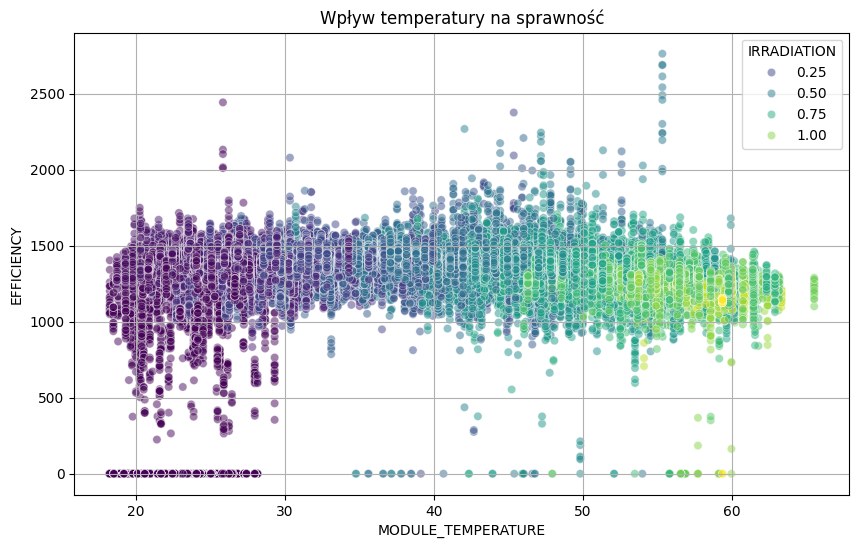

In [8]:
plt.figure(figsize=(10,6))
sbn.scatterplot(data=df, x='MODULE_TEMPERATURE', y='EFFICIENCY', hue='IRRADIATION', palette='viridis', alpha=0.5)
plt.title('Wpływ temperatury na sprawność')
plt.grid(True)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

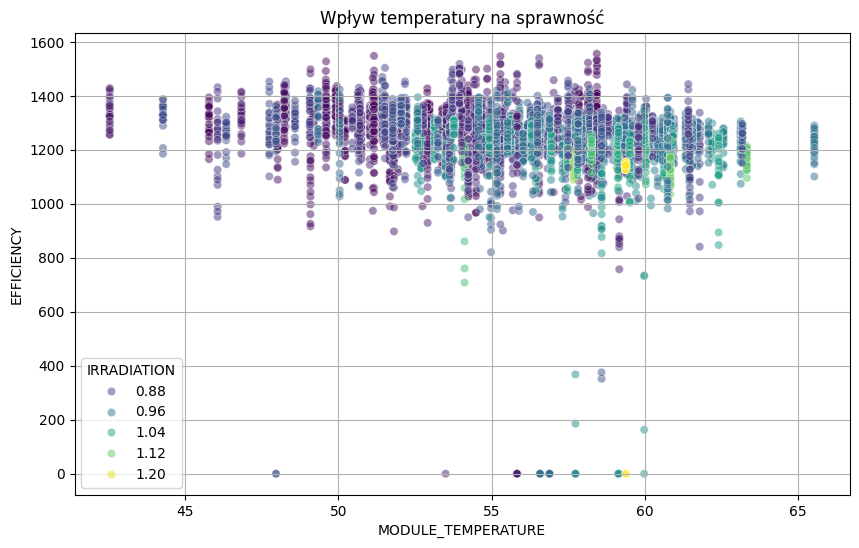

In [9]:
df = df[df['IRRADIATION'] > 0.8]
plt.figure(figsize=(10,6))
sbn.scatterplot(data=df, x='MODULE_TEMPERATURE', y='EFFICIENCY', hue='IRRADIATION', palette='viridis', alpha=0.5)
plt.title('Wpływ temperatury na sprawność')
plt.grid(True)
plt.show


In [10]:
columns = ['EFFICIENCY', 'MODULE_TEMPERATURE', 'IRRADIATION']
print(df[columns].corr())

                    EFFICIENCY  MODULE_TEMPERATURE  IRRADIATION
EFFICIENCY            1.000000           -0.182399    -0.249434
MODULE_TEMPERATURE   -0.182399            1.000000     0.482066
IRRADIATION          -0.249434            0.482066     1.000000


<Axes: xlabel='MODULE_TEMPERATURE', ylabel='EFFICIENCY'>

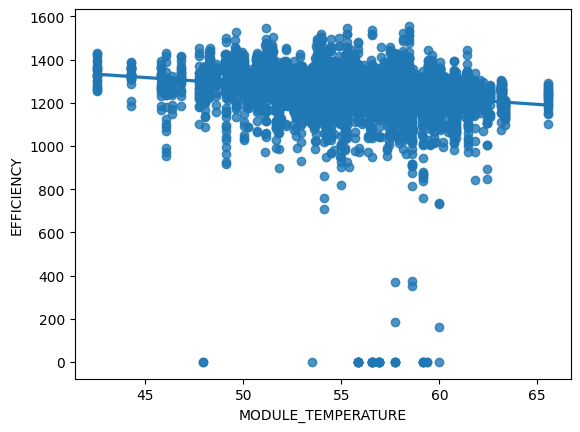

In [11]:
sbn.regplot(data=df, x='MODULE_TEMPERATURE', y='EFFICIENCY')

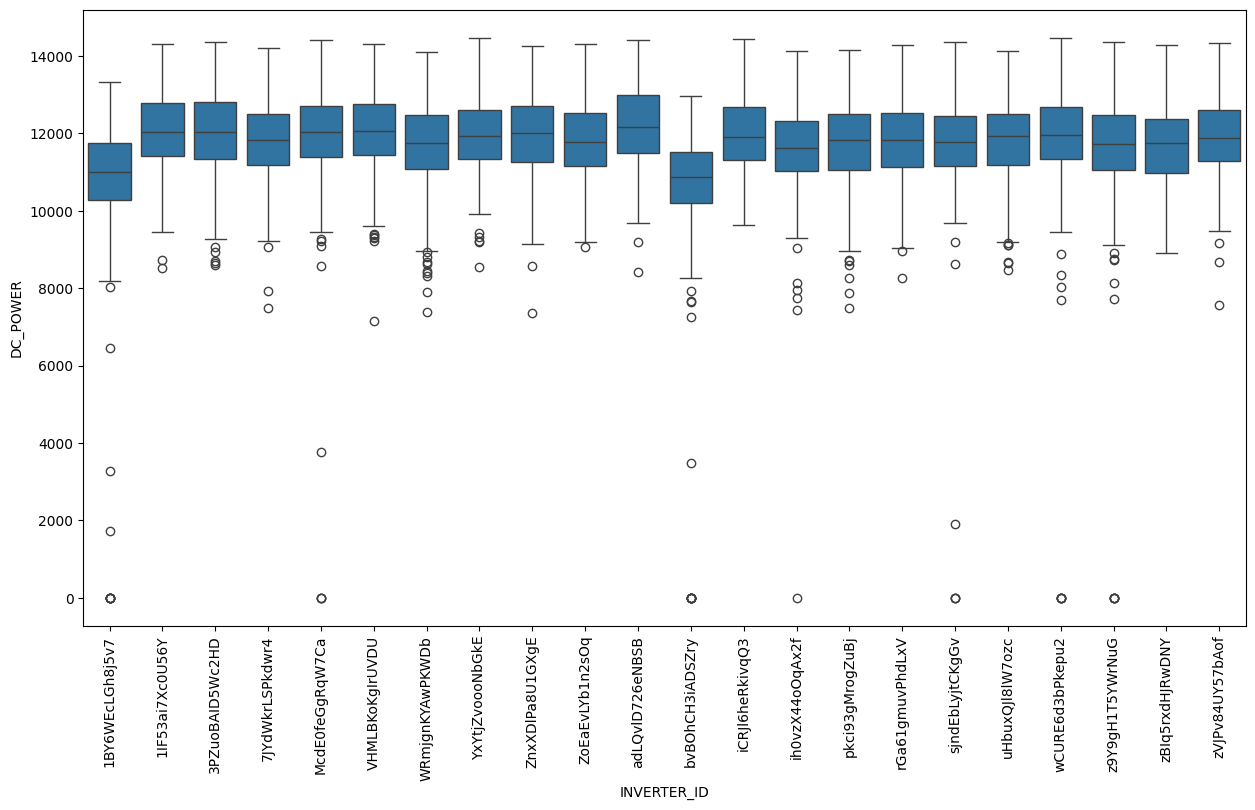

In [12]:
df = df.rename(columns={'SOURCE_KEY_x': 'INVERTER_ID'})
plt.figure(figsize=(15, 8))
sbn.boxplot(data=df, x='INVERTER_ID',y='DC_POWER')
plt.xticks(rotation=90)
plt.show()

In [13]:
total_yield = df.groupby('INVERTER_ID')['DC_POWER'].sum()

In [14]:
total_yield.median()

2550199.0387204997

In [15]:
df.groupby('INVERTER_ID')['DC_POWER'].sum().sort_values()

,DC_POWER
INVERTER_ID,
bvBOhCH3iADSZry,2.263525e+06
1BY6WEcLGh8j5v7,2.298095e+06
z9Y9gH1T5YWrNuG,2.485455e+06
ih0vzX44oOqAx2f,2.501028e+06
sjndEbLyjtCKgGv,2.512870e+06
WRmjgnKYAwPKWDb,2.522345e+06
pkci93gMrogZuBj,2.529469e+06
wCURE6d3bPkepu2,2.531695e+06
rGa61gmuvPhdLxV,2.540213e+06


In [16]:
x = (2550199.0387204997 - 2.263525e+06) / 2550199.0387204997
print(x)

0.11241241737128543


In [17]:
faulty_inv = df[df['INVERTER_ID'] == '1BY6WEcLGh8j5v7']
healthy_inv = df[df['INVERTER_ID'] == 'McdE0feGgRqW7Ca']

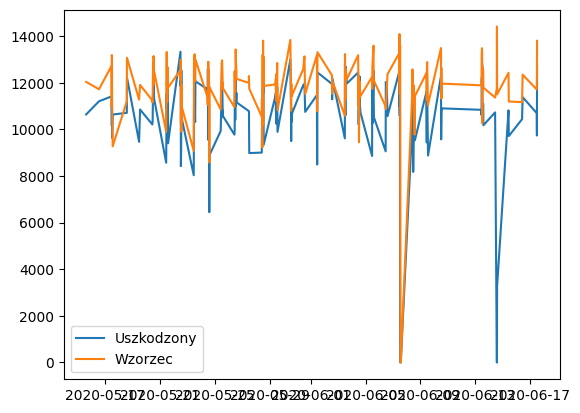

In [18]:
plt.plot('DATE_TIME', 'DC_POWER', data=faulty_inv, label='Uszkodzony')
plt.plot('DATE_TIME', 'DC_POWER', data=healthy_inv, label='Wzorzec')
plt.legend()